<a href="https://colab.research.google.com/github/goalic/Programowanie2/blob/main/PROJEKT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
!wget https://github.com/goalic/Programowanie2/blob/main/Video_Game_Sales_as_of_Jan_2017.csv

--2026-06-10 16:55:42--  https://github.com/goalic/Programowanie2/blob/main/Video_Game_Sales_as_of_Jan_2017.csv
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘Video_Game_Sales_as_of_Jan_2017.csv.1’

Video_Game_Sales_as     [ <=>                ] 223.83K  --.-KB/s    in 0.03s   

2026-06-10 16:55:43 (6.78 MB/s) - ‘Video_Game_Sales_as_of_Jan_2017.csv.1’ saved [229206]



In [52]:
import pandas as pd

csv_url = 'https://raw.githubusercontent.com/goalic/Programowanie2/main/Video_Game_Sales_as_of_Jan_2017.csv'

fred = pd.read_csv(csv_url)

fred.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E
4,Pokemon Red/Pokemon Blue,G,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN


In [53]:
fred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17416 entries, 0 to 17415
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             17416 non-null  object 
 1   Platform         17416 non-null  object 
 2   Year_of_Release  17408 non-null  float64
 3   Genre            17416 non-null  object 
 4   Publisher        17415 non-null  object 
 5   NA_Sales         17416 non-null  float64
 6   EU_Sales         17416 non-null  float64
 7   JP_Sales         17416 non-null  float64
 8   Other_Sales      17416 non-null  float64
 9   Global_Sales     17416 non-null  float64
 10  Critic_Score     8336 non-null   float64
 11  Critic_Count     8336 non-null   float64
 12  User_Score       7798 non-null   float64
 13  User_Count       7798 non-null   float64
 14  Rating           10252 non-null  object 
dtypes: float64(10), object(5)
memory usage: 2.0+ MB


In [54]:
fred.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,17408.000000,17416.000000,17416.000000,17416.000000,17416.000000,17416.000000,8336.000000,8336.000000,7798.000000,7798.000000
mean,2006.630859,0.254534,0.140727,0.075020,0.045908,0.516469,68.912548,26.192059,7.117056,162.672480
std,5.901598,0.800673,0.497341,0.303412,0.183932,1.526124,13.964937,18.991526,1.502410,562.837954
min,1976.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.050000,60.000000,11.000000,6.400000,10.000000
50%,2008.000000,0.070000,0.020000,0.000000,0.010000,0.160000,71.000000,21.000000,7.500000,25.000000
75%,2011.000000,0.230000,0.100000,0.030000,0.030000,0.450000,79.000000,36.000000,8.200000,81.000000
max,2017.000000,41.360000,28.960000,10.220000,10.570000,82.540000,98.000000,113.000000,9.700000,10766.000000


In [55]:
fred["Year_of_Release"].value_counts()

,count
Year_of_Release,
2009.0,1550
2008.0,1536
2010.0,1331
2007.0,1262
2011.0,1215
2006.0,1067
2005.0,968
2002.0,869
2003.0,801


In [56]:
fred["Global_Sales"].value_counts()

,count
Global_Sales,
0.01,1239
0.02,1107
0.03,848
0.04,670
0.05,622
...,...
4.70,1
4.68,1
4.67,1


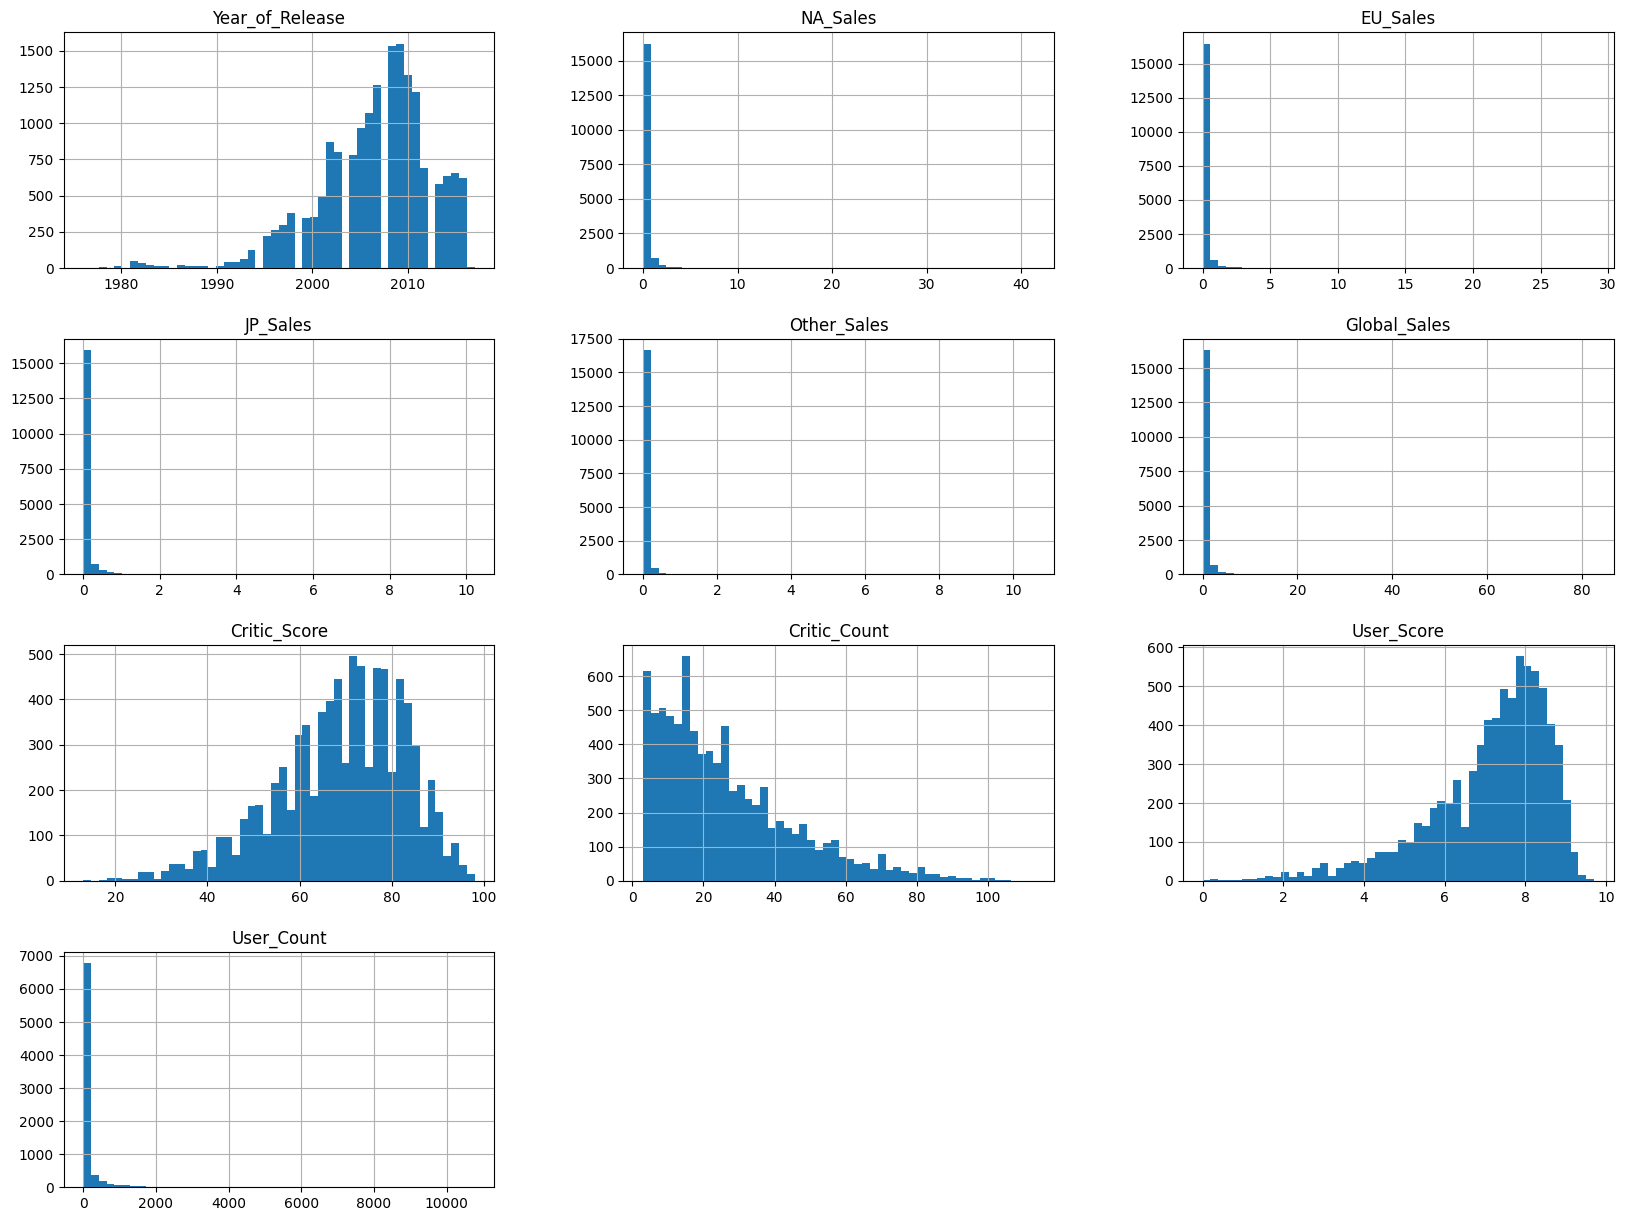

In [57]:
%matplotlib inline
import matplotlib.pyplot as plt
fred.hist(bins=50, figsize=(20,15))
plt.show()

TEST SPLIT

In [58]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(fred, test_size=0.2, random_state=42)

In [59]:
import numpy as np

fred["income_cat"] = np.ceil(fred["Global_Sales"] / 1.5)
fred["income_cat"] = fred["income_cat"].clip(upper=5)
display(fred[["Global_Sales", "income_cat"]].head())

,Global_Sales,income_cat
0,82.54,5.0
1,40.24,5.0
2,35.57,5.0
3,32.78,5.0
4,31.37,5.0


In [60]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(fred, fred["income_cat"]):
  strat_train_set = fred.loc[train_index]
  strat_test_set = fred.loc[test_index]

In [61]:
fred["income_cat"].value_counts() / len(fred)

,count
income_cat,
1.0,0.927423
2.0,0.045131
3.0,0.013321
5.0,0.008498
4.0,0.005627


In [62]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

display(strat_train_set.head())

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
6353,NASCAR 06: Total Team Control,X,2005.0,Racing,Electronic Arts,0.20,0.06,0.00,0.01,0.27,79.0,25.0,5.9,7.0,E
6329,Slam Dunk: Yonkyo Taiketsu!!,SNES,1994.0,Sports,Namco Bandai Games,0.00,0.00,0.27,0.00,0.27,NaN,NaN,NaN,NaN,NaN
1762,Your Shape: Fitness Evolved 2012,X360,2011.0,Sports,Ubisoft,0.70,0.36,0.00,0.10,1.16,77.0,13.0,7.6,21.0,E
9497,Shaman King: Power of Spirit,PS2,2004.0,Adventure,Konami Digital Entertainment,0.06,0.05,0.00,0.02,0.13,54.0,9.0,8.2,17.0,T
13815,Devil May Cry 4,PC,2008.0,Action,Capcom,0.01,0.02,0.00,0.01,0.04,78.0,21.0,8.5,355.0,M


In [63]:
fred = strat_train_set.copy()

WIZUALIZACJE

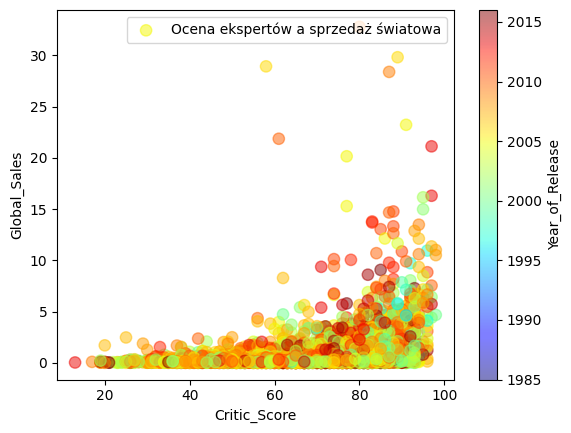

In [64]:
fred.plot(kind="scatter", x="Critic_Score", y="Global_Sales", alpha=0.5,
s=fred["Year_of_Release"]/30, label="Ocena ekspertów a sprzedaż światowa",
c="Year_of_Release", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.show()

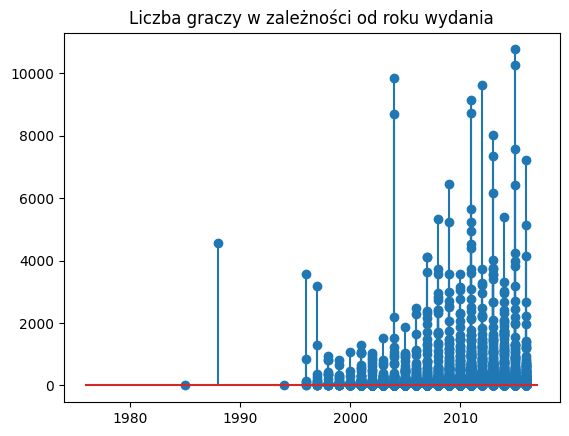

In [65]:
plt.stem(fred["Year_of_Release"], fred["User_Count"])
plt.title("Liczba graczy w zależności od roku wydania")
plt.show()

KORELACJE

In [66]:
attributes = ["Critic_Score", "Global_Sales", "Year_of_Release"]
fred[attributes].corr()

,Critic_Score,Global_Sales,Year_of_Release
Critic_Score,1.000000,0.286747,0.02163
Global_Sales,0.286747,1.000000,-0.08482
Year_of_Release,0.021630,-0.084820,1.00000


In [67]:
numeric_cols = fred.select_dtypes(include=['number']).columns

correlations_with_Global_Sales = fred[numeric_cols].corr()['Global_Sales'].sort_values(ascending=False)

display(correlations_with_Global_Sales)

,Global_Sales
Global_Sales,1.000000
NA_Sales,0.927741
EU_Sales,0.884918
Other_Sales,0.732333
JP_Sales,0.637766
Critic_Count,0.353276
User_Count,0.321136
Critic_Score,0.286747
User_Score,0.094129
Year_of_Release,-0.084820


array([[<Axes: xlabel='Critic_Score', ylabel='Critic_Score'>,
        <Axes: xlabel='Global_Sales', ylabel='Critic_Score'>,
        <Axes: xlabel='Year_of_Release', ylabel='Critic_Score'>,
        <Axes: xlabel='EU_Sales', ylabel='Critic_Score'>],
       [<Axes: xlabel='Critic_Score', ylabel='Global_Sales'>,
        <Axes: xlabel='Global_Sales', ylabel='Global_Sales'>,
        <Axes: xlabel='Year_of_Release', ylabel='Global_Sales'>,
        <Axes: xlabel='EU_Sales', ylabel='Global_Sales'>],
       [<Axes: xlabel='Critic_Score', ylabel='Year_of_Release'>,
        <Axes: xlabel='Global_Sales', ylabel='Year_of_Release'>,
        <Axes: xlabel='Year_of_Release', ylabel='Year_of_Release'>,
        <Axes: xlabel='EU_Sales', ylabel='Year_of_Release'>],
       [<Axes: xlabel='Critic_Score', ylabel='EU_Sales'>,
        <Axes: xlabel='Global_Sales', ylabel='EU_Sales'>,
        <Axes: xlabel='Year_of_Release', ylabel='EU_Sales'>,
        <Axes: xlabel='EU_Sales', ylabel='EU_Sales'>]], dtype=objec

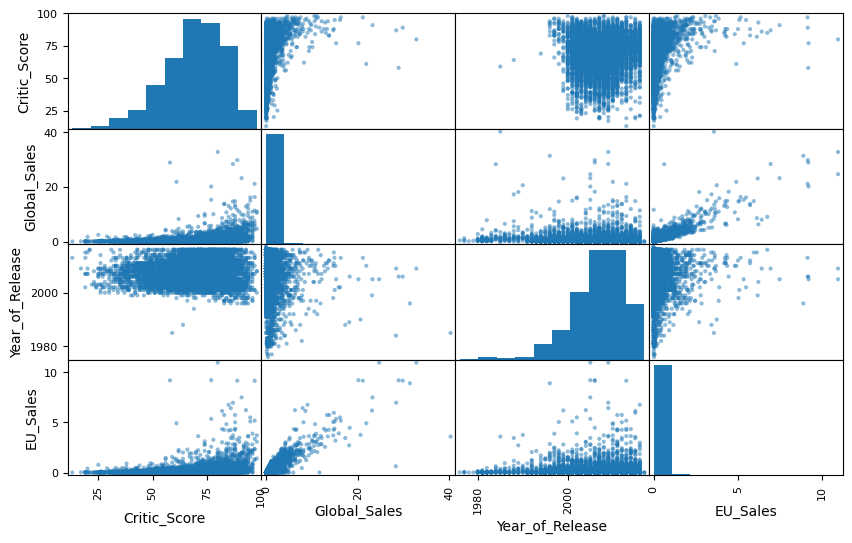

In [68]:
from pandas.plotting import scatter_matrix
attributes = ["Critic_Score", "Global_Sales", "Year_of_Release", "EU_Sales"]
scatter_matrix(fred[attributes], figsize=(10, 6))

In [69]:
fred_num = fred.drop("Name", axis = 1)

In [70]:
fred_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13932 entries, 6353 to 17380
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Platform         13932 non-null  object 
 1   Year_of_Release  13926 non-null  float64
 2   Genre            13932 non-null  object 
 3   Publisher        13931 non-null  object 
 4   NA_Sales         13932 non-null  float64
 5   EU_Sales         13932 non-null  float64
 6   JP_Sales         13932 non-null  float64
 7   Other_Sales      13932 non-null  float64
 8   Global_Sales     13932 non-null  float64
 9   Critic_Score     6648 non-null   float64
 10  Critic_Count     6648 non-null   float64
 11  User_Score       6239 non-null   float64
 12  User_Count       6239 non-null   float64
 13  Rating           8206 non-null   object 
dtypes: float64(10), object(4)
memory usage: 1.6+ MB


In [71]:
fred_cat = fred.select_dtypes(include=['object']).copy()
display(fred_cat.head())

,Name,Platform,Genre,Publisher,Rating
6353,NASCAR 06: Total Team Control,X,Racing,Electronic Arts,E
6329,Slam Dunk: Yonkyo Taiketsu!!,SNES,Sports,Namco Bandai Games,NaN
1762,Your Shape: Fitness Evolved 2012,X360,Sports,Ubisoft,E
9497,Shaman King: Power of Spirit,PS2,Adventure,Konami Digital Entertainment,T
13815,Devil May Cry 4,PC,Action,Capcom,M


One-Hot Encoding

In [72]:
categorical_features = ['Platform', 'Genre', 'Publisher', 'Rating']
fred_encoded = pd.get_dummies(fred, columns=categorical_features, drop_first=False)

display(fred_encoded.head())

,Name,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,...,"Publisher_mixi, Inc",Publisher_responDESIGN,Rating_AO,Rating_E,Rating_E10+,Rating_EC,Rating_K-A,Rating_M,Rating_RP,Rating_T
6353,NASCAR 06: Total Team Control,2005.0,0.20,0.06,0.00,0.01,0.27,79.0,25.0,5.9,...,False,False,False,True,False,False,False,False,False,False
6329,Slam Dunk: Yonkyo Taiketsu!!,1994.0,0.00,0.00,0.27,0.00,0.27,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1762,Your Shape: Fitness Evolved 2012,2011.0,0.70,0.36,0.00,0.10,1.16,77.0,13.0,7.6,...,False,False,False,True,False,False,False,False,False,False
9497,Shaman King: Power of Spirit,2004.0,0.06,0.05,0.00,0.02,0.13,54.0,9.0,8.2,...,False,False,False,False,False,False,False,False,False,True
13815,Devil May Cry 4,2008.0,0.01,0.02,0.00,0.01,0.04,78.0,21.0,8.5,...,False,False,False,False,False,False,False,True,False,False


In [73]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

fred_labels = fred['Global_Sales'].copy()
fred_features = fred.drop('Global_Sales', axis=1)

num_attribs_features = ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Year_of_Release']
cat_attribs = ["Platform", "Genre", "Publisher", "Rating"]

num_pipeline = Pipeline([
  ('imputer', SimpleImputer(strategy="median")),
  ('std_scaler', StandardScaler())])

cat_pipeline = Pipeline([
  ('imputer', SimpleImputer(strategy="most_frequent")),
  ('one_hot', OneHotEncoder(handle_unknown='ignore'))])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs_features),
    ("cat", cat_pipeline, cat_attribs)])

fred_prepared = full_pipeline.fit_transform(fred_features)

fred_prepared.shape

(13932, 634)

In [74]:
fred_prepared_dense = fred_prepared.toarray()

Y_train = fred_labels
X_train = fred_prepared_dense

print(f"X_train: {X_train.shape}")
print(f"Y_train: {Y_train.shape}")

X_train: (13932, 634)
Y_train: (13932,)


In [75]:
strat_test_labels = strat_test_set['Global_Sales'].copy()
strat_test_features = strat_test_set.drop('Global_Sales', axis=1)

strat_test_prepared = full_pipeline.transform(strat_test_features)

strat_test_set_prepared_dense = strat_test_prepared.toarray()

Y_test = strat_test_labels
X_test = strat_test_set_prepared_dense

print(f"X_test: {X_test.shape}")
print(f"Y_test: {Y_test.shape}")

X_test: (3484, 634)
Y_test: (3484,)


MODEL 1: REGRESJA LINIOWA

In [76]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

LinearRegression()

Zbiór treningowy:

In [77]:
from sklearn.metrics import mean_squared_error
regresja = lin_reg.predict(X_train)
lin_mse = mean_squared_error(Y_train, regresja)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(1.2057784274933785)

In [78]:
def display_scores(scores):
 print("Scores:", scores)
 print("Mean:", scores.mean())
 print("Standard deviation:", scores.std())

In [79]:
from sklearn.model_selection import cross_val_score

lin_scores = cross_val_score(lin_reg, X_train, Y_train, scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [1.2570485  0.94981308 1.28735141 1.59616831 1.06136925 0.89822022
 1.3031652  1.18005733 1.38179112 1.14752898]
Mean: 1.2062513391277274
Standard deviation: 0.1967659363451332


Zbiór testowy:

In [80]:
from sklearn.metrics import mean_squared_error
test_regresja = lin_reg.predict(X_test)
lin_mse = mean_squared_error(Y_test, test_regresja)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(1.8363983798433348)

MODEL 2: RANDOM FOREST REGRESSOR

In [81]:
from sklearn.ensemble import RandomForestRegressor

In [82]:
forest_reg = RandomForestRegressor()
forest_reg.fit(X_train, Y_train)

las = forest_reg.predict(X_train)
forest_mse = mean_squared_error(Y_train, las)
forest_rmse = np.sqrt(forest_mse)

forest_rmse

np.float64(0.5430917466472656)

In [83]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(forest_reg, X_train, Y_train,
scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-scores)

In [84]:
display_scores(forest_rmse_scores)

Scores: [1.26851272 0.85714215 1.2338737  1.49973994 0.85012693 0.77532578
 1.20794652 0.92149541 1.32804906 1.05696567]
Mean: 1.0999177882638287
Standard deviation: 0.23028572608976527


Na zbiorze testowym:

In [85]:
test_predictions = forest_reg.predict(X_test)
forest_mse_test = mean_squared_error(Y_test, test_predictions)
forest_rmse_test = np.sqrt(forest_mse_test)

In [86]:
display_scores(forest_rmse_test)

Scores: 1.7044677734563958
Mean: 1.7044677734563958
Standard deviation: 0.0


In [87]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [88]:
grid_search.best_params_

{'max_features': 4, 'n_estimators': 30}

In [89]:
grid_search.best_estimator_

RandomForestRegressor(max_features=4, n_estimators=30, random_state=42)

Ocena hiperparamentrów na zbiorze testowym

In [90]:
best_model = grid_search.best_estimator_

In [91]:
test_pred = best_model.predict(X_test)

In [92]:
test_estim = mean_squared_error(Y_test, test_pred)

In [93]:
final_rmse = np.sqrt(test_estim)
final_rmse

np.float64(1.682962839071397)

In [94]:
print(f"RMSE dla Random Forest z hiperparametrami: {final_rmse:.4f}")
print(f"RMSE dla regresji liniowej: {lin_rmse:.4f}")

RMSE dla Random Forest z hiperparametrami: 1.6830
RMSE dla regresji liniowej: 1.8364
